# GTEx k-means clustering of gene expression data using different methods

This notebook evaluates the ability of different dimensionality reduction methods to preserve biological tissue structure in GTEx gene expression data. It performs GPU-accelerated K-means clustering (using cuML) on sample embeddings from multiple methods-including raw RNA-Seq, CLAMP (full and base), PCA, ICA, NMF, PLIER, Flashier, MOFA-flex, and GenomicSuperSignature. Then measures clustering quality using the Adjusted Rand Index (ARI) against the 31 known GTEx tissue labels. The analysis runs an ensemble of K-means with varying cluster numbers (k=20-40) and random seeds to determine which embeddings best capture the underlying tissue biology.

## Libraries

💡 **Environment:** `gpu-kmeans` 

In [1]:
import csv
import gc
from pathlib import Path
import numpy as np
import pandas as pd
from pyprojroot.here import here
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score as ari
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import cupy as cp
from cuml.cluster import KMeans as cuKMeans
import matplotlib.pyplot as plt
import pickle
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import re
from scipy.stats import mannwhitneyu
readRDS = ro.r["readRDS"]

In [2]:
# Define consistent color palette for all models across all plots
# Using distinct, non-repeating colors for clear visual distinction

MODEL_COLORS = {
    # CLAMP models
    "CLAMP_BP": "#0077BB",           # strong blue
    "CLAMP_base": "#33BBEE",         # cyan
    "CLAMP_KEGG": "#009988",         # teal
    "CLAMP_CellMarker": "#7B68EE",   # medium slate blue
    "CLAMP_GTEx": "#006400",         # dark green
    
    # Other informed methods
    "PLIER": "#EE7733",              # orange
    "GenomicSuperSignature": "#AA3377",  # wine/magenta
    
    # Unsupervised methods
    "RNA-Seq": "#CC3311",            # red
    "PCA": "#EE3377",                # magenta/pink
    "ICA": "#888888",                # gray
    "NMF": "#DDCC77",                # sand/gold
    "Flashier": "#44AA99",           # teal-green
    "MOFA-FLEX_base": "#882255",     # dark purple
    "MOFA-FLEX_BP": "#117733",       # forest green
    "WGCNA": "#999933",              # olive
}

# Color palette for RNA-Seq gene fraction plots - completely different from all model colors
RNASEQ_FRACTION_COLORS = {
    "100%": "#332288",   # indigo
    "75%": "#6699CC",    # steel blue
    "50%": "#661100",    # dark brown
    "25%": "#BBBBBB",    # light gray
}

def get_model_color(model_name):
    """Get consistent color for a model name."""
    return MODEL_COLORS.get(model_name, "#333333")  # default to dark gray if not found

def get_fraction_color(fraction_label):
    """Get consistent color for RNA-Seq fraction label."""
    return RNASEQ_FRACTION_COLORS.get(fraction_label, "#333333")

# Input

In [3]:
path = here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')

gtex_meta = pd.read_csv(
    path,
    sep='\t',
    header=0,
    dtype=str,
    quoting=csv.QUOTE_NONE,   
    engine='python',
    comment=None,            
    keep_default_na=False,
    on_bad_lines='warn'     
)

print(gtex_meta.shape)
gtex_meta.head()

(22951, 63)


,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
0,GTEX-1117F-0003-SM-58Q7G,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
1,GTEX-1117F-0003-SM-5DWSB,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
2,GTEX-1117F-0003-SM-6WBT7,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
3,GTEX-1117F-0011-R10a-SM-AHZ7F,,"B1, A1",,,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,
4,GTEX-1117F-0011-R10b-SM-CYKQ8,,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,


In [4]:
display(gtex_meta['SMTS'].value_counts())
total_tissues = len(gtex_meta['SMTS'].value_counts())
total_tissues

SMTS
Blood              3480
Brain              3326
Skin               2014
Esophagus          1582
Blood Vessel       1473
Adipose Tissue     1327
Heart              1141
Muscle             1132
Lung                867
Colon               821
Thyroid             812
Nerve               722
Breast              480
Testis              406
Stomach             381
Pancreas            360
Pituitary           301
Adrenal Gland       275
Prostate            262
Spleen              260
Liver               251
Bone Marrow         217
Ovary               195
Small Intestine     193
Salivary Gland      181
Vagina              173
Uterus              166
Kidney              104
Bladder              21
Cervix Uteri         19
Fallopian Tube        9
Name: count, dtype: int64

31

Keep samples in expression and in metadata

In [5]:
gtex_data = pd.read_csv(here('output/gtex/df_gtex_fbm_filt.csv'), index_col=0)

In [6]:
meta = gtex_meta.copy()
if meta.index.name != "SAMPID":
    meta = meta.set_index("SAMPID")

sample_ids_expr = pd.Index(gtex_data.columns.astype(str).str.strip(), name="SAMPID")
sample_ids_meta = meta.index.astype(str).str.strip()
common_ids = sample_ids_expr.intersection(sample_ids_meta)

if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between expression and metadata.")

gtex_data_common = gtex_data.loc[:, common_ids]    
meta_common = meta.loc[common_ids] 

In [7]:
y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# GPU kmeans ensemble

## Parameters

In [8]:
BASE_SEED = 10000  # Base seed for reproducible k-means
K_MIN = 20
K_MAX = 40
K_STEP = 5
N_REPS_PER_K = 50
KMEANS_N_INIT = 10

# K values
k_values = list(range(K_MIN, K_MAX + 1, K_STEP))
if total_tissues not in k_values:
    k_values.append(total_tissues)
k_values = sorted(set(k_values))

print("BASE_SEED:", BASE_SEED)
print("K_MIN:", K_MIN)
print("K_MAX:", K_MAX)
print("K_STEP:", K_STEP)
print("N_REPS_PER_K:", N_REPS_PER_K)
print("KMEANS_N_INIT:", KMEANS_N_INIT)
print("total_tissues:", total_tissues)
print("k_values:", k_values)

BASE_SEED: 10000
K_MIN: 20
K_MAX: 40
K_STEP: 5
N_REPS_PER_K: 50
KMEANS_N_INIT: 10
total_tissues: 31
k_values: [20, 25, 30, 31, 35, 40]


In [9]:
def run_kmeans_compare_scaling(B_t, y_true, method_name, base_seed_offset=0):
    """
    Run k-means clustering with and without StandardScaler.
    Returns the best approach based on mean ARI at optimal k.
    
    Parameters:
    -----------
    B_t : array-like
        Transposed data matrix (samples x features)
    y_true : array-like
        True labels for ARI computation
    method_name : str
        Name of the method (for labeling results)
    base_seed_offset : int
        Offset to add to BASE_SEED for this method (ensures different seeds per method)
    
    Returns:
    --------
    dict with keys:
        - 'best_results_df': DataFrame with results from best approach
        - 'best_k_results_df': DataFrame filtered to best k
        - 'best_k': optimal number of clusters
        - 'best_approach': 'scaled' or 'unscaled'
        - 'scaled_ari': mean ARI at best k with scaling
        - 'unscaled_ari': mean ARI at best k without scaling
    """
    results = {}
    
    for approach in ['scaled', 'unscaled']:
        if approach == 'scaled':
            scaler = StandardScaler()
            X = scaler.fit_transform(B_t)
        else:
            X = B_t.values if hasattr(B_t, 'values') else B_t
        
        X_gpu = cp.asarray(X.astype("float32"))
        
        records = []
        for k in k_values:
            for rep in range(N_REPS_PER_K):
                km = cuKMeans(
                    n_clusters=k,
                    init="k-means++",
                    random_state=BASE_SEED + base_seed_offset + k * 1000 + rep,
                    max_iter=300,
                    tol=1e-4,
                    verbose=0
                )
                labels_gpu = km.fit_predict(X_gpu)
                labels = cp.asnumpy(labels_gpu)
                ari = adjusted_rand_score(y_true, labels)
                
                records.append({
                    "k": k,
                    "rep": rep,
                    "seed": BASE_SEED + base_seed_offset + k * 1000 + rep,
                    "ari": ari,
                    "approach": approach
                })
        
        del X_gpu
        cp.get_default_memory_pool().free_all_blocks()
        
        df = pd.DataFrame.from_records(records)
        mean_ari = df.groupby("k")["ari"].mean()
        best_k = mean_ari.idxmax()
        best_k_df = df[df["k"] == best_k]
        
        results[approach] = {
            'df': df,
            'best_k': best_k,
            'best_k_df': best_k_df,
            'best_k_mean_ari': mean_ari[best_k]
        }
    
    # Compare and select best approach
    if results['scaled']['best_k_mean_ari'] >= results['unscaled']['best_k_mean_ari']:
        best_approach = 'scaled'
    else:
        best_approach = 'unscaled'
    
    best = results[best_approach]
    
    print(f"{method_name}:")
    print(f"  Scaled   - Best k: {results['scaled']['best_k']}, Mean ARI: {results['scaled']['best_k_mean_ari']:.4f}")
    print(f"  Unscaled - Best k: {results['unscaled']['best_k']}, Mean ARI: {results['unscaled']['best_k_mean_ari']:.4f}")
    print(f"  Selected: {best_approach.upper()}")
    
    return {
        'best_results_df': best['df'],
        'best_k_results_df': best['best_k_df'],
        'best_k': best['best_k'],
        'best_approach': best_approach,
        'scaled_ari': results['scaled']['best_k_mean_ari'],
        'unscaled_ari': results['unscaled']['best_k_mean_ari'],
        'all_results': results
    }

## RNA-Seq

K-means clustering is highly sensitive to the number of input features, which is particularly important when comparing full RNA-seq expression profiles (highest dimensional) to lower-dimensional latent variable (LV) representations. High dimensionality can also reduce the discriminative value of Euclidean distances: as dimensionality increases, pairwise distances between samples tend to become more similar (an “equidistance” effect), making it harder for k-means to separate clusters reliably and exacerbating the curse of dimensionality. To reduce these effects, we restricted the RNA-seq input to the most variable genes and ran k-means using 100% of this set, then repeated the analysis using 75%, 50%, and 25% of the most variable genes.

In [10]:
# Gene selection by variance configuration
GENE_FRACTIONS = [1.0, 0.75, 0.50, 0.25]

# Prepare RNA-Seq data
B = gtex_data.copy()
B.columns = B.columns.astype(str).str.strip()
common_ids = B.columns.intersection(meta.index)
B_common = B.loc[:, common_ids]

all_genes = B_common.index.tolist()
n_genes = len(all_genes)
y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Compute gene variances and rank genes by variance (descending)
gene_variances = B_common.var(axis=1)
genes_by_variance = gene_variances.sort_values(ascending=False).index.tolist()

print(f"Total genes: {n_genes}")
print(f"Total samples: {len(common_ids)}")

# Store all results
rnaseq_topvar_results = {}

for frac in GENE_FRACTIONS:
    pct = int(frac * 100)
    run_label = f"rnaseq_{pct}pct_topvar"
    print(f"\n{'='*50}")
    print(f"Running: {run_label}")
    
    # Select top variable genes
    n_select = int(n_genes * frac)
    selected_genes = genes_by_variance[:n_select]
    print(f"  Selected top {n_select} most variable genes")
    
    # Prepare data
    B_subset = B_common.loc[selected_genes, :]
    B_t = B_subset.T.astype(np.float32)
    
    # Run k-means with both scaling approaches
    results = run_kmeans_compare_scaling(
        B_t, y_true, 
        run_label, 
        base_seed_offset=int(frac * 1000000)
    )
    
    rnaseq_topvar_results[run_label] = results

print("\n" + "="*50)
print("\nTop Variable Genes Analysis Summary:")
for label, results in rnaseq_topvar_results.items():
    print(f"  {label}: Best approach = {results['best_approach']}, Best k = {results['best_k']}, ARI = {results['scaled_ari'] if results['best_approach'] == 'scaled' else results['unscaled_ari']:.4f}")

Total genes: 21613
Total samples: 17382

Running: rnaseq_100pct_topvar
  Selected top 21613 most variable genes
rnaseq_100pct_topvar:
  Scaled   - Best k: 25, Mean ARI: 0.5975
  Unscaled - Best k: 25, Mean ARI: 0.5975
  Selected: SCALED

Running: rnaseq_75pct_topvar
  Selected top 16209 most variable genes
rnaseq_75pct_topvar:
  Scaled   - Best k: 25, Mean ARI: 0.6095
  Unscaled - Best k: 25, Mean ARI: 0.6095
  Selected: SCALED

Running: rnaseq_50pct_topvar
  Selected top 10806 most variable genes
rnaseq_50pct_topvar:
  Scaled   - Best k: 25, Mean ARI: 0.5960
  Unscaled - Best k: 25, Mean ARI: 0.5960
  Selected: SCALED

Running: rnaseq_25pct_topvar
  Selected top 5403 most variable genes
rnaseq_25pct_topvar:
  Scaled   - Best k: 25, Mean ARI: 0.5214
  Unscaled - Best k: 25, Mean ARI: 0.5214
  Selected: SCALED


Top Variable Genes Analysis Summary:
  rnaseq_100pct_topvar: Best approach = scaled, Best k = 25, ARI = 0.5975
  rnaseq_75pct_topvar: Best approach = scaled, Best k = 25, ARI = 

In [11]:
# Select best configuration from top variable genes analysis
best_mean_ari = -1
best_run_label = None

for run_label, results in rnaseq_topvar_results.items():
    # Use the best approach's ARI for comparison
    ari = results['scaled_ari'] if results['best_approach'] == 'scaled' else results['unscaled_ari']
    if ari > best_mean_ari:
        best_mean_ari = ari
        best_run_label = run_label

print(f"Best RNA-Seq configuration: {best_run_label}")
print(f"  Approach: {rnaseq_topvar_results[best_run_label]['best_approach']}")
print(f"  Best k: {rnaseq_topvar_results[best_run_label]['best_k']}")
print(f"  Mean ARI: {best_mean_ari:.4f}")

# Set the best results for use in comparisons
gtex_rnaseq_kmeans_results_df = rnaseq_topvar_results[best_run_label]['best_results_df']
best_k_gtex_rnaseq_kmeans_results_df = rnaseq_topvar_results[best_run_label]['best_k_results_df']

# Create best_k_rnaseq_results for the gene fraction comparison plots
best_k_rnaseq_results = {}
for run_label, results in rnaseq_topvar_results.items():
    # Extract fraction from run_label (e.g., 'rnaseq_75pct_topvar' -> 0.75)
    pct = int(run_label.split('_')[1].replace('pct', ''))
    frac = pct / 100.0
    
    df = results['best_k_results_df'].copy()
    df['frac'] = frac
    best_k_rnaseq_results[run_label] = df

Best RNA-Seq configuration: rnaseq_75pct_topvar
  Approach: scaled
  Best k: 25
  Mean ARI: 0.6095


In [12]:
# Print Summary of all RNA-Seq configurations
print("\n" + "="*60)
print("SUMMARY: RNA-Seq Top Variable Genes Analysis")
print("="*60)

for run_label, results in rnaseq_topvar_results.items():
    best_ari = results['scaled_ari'] if results['best_approach'] == 'scaled' else results['unscaled_ari']
    print(f"{run_label}:")
    print(f"    Best approach: {results['best_approach']}")
    print(f"    Best k: {results['best_k']}")
    print(f"    Scaled ARI: {results['scaled_ari']:.4f}")
    print(f"    Unscaled ARI: {results['unscaled_ari']:.4f}")
    print()


SUMMARY: RNA-Seq Top Variable Genes Analysis
rnaseq_100pct_topvar:
    Best approach: scaled
    Best k: 25
    Scaled ARI: 0.5975
    Unscaled ARI: 0.5975

rnaseq_75pct_topvar:
    Best approach: scaled
    Best k: 25
    Scaled ARI: 0.6095
    Unscaled ARI: 0.6095

rnaseq_50pct_topvar:
    Best approach: scaled
    Best k: 25
    Scaled ARI: 0.5960
    Unscaled ARI: 0.5960

rnaseq_25pct_topvar:
    Best approach: scaled
    Best k: 25
    Scaled ARI: 0.5214
    Unscaled ARI: 0.5214



In [13]:
# Select best configuration from top variable genes analysis
best_mean_ari = -1
best_run_label = None

for run_label, results in rnaseq_topvar_results.items():
    # Use the best approach's ARI for comparison
    ari = results['scaled_ari'] if results['best_approach'] == 'scaled' else results['unscaled_ari']
    if ari > best_mean_ari:
        best_mean_ari = ari
        best_run_label = run_label

print(f"Best RNA-Seq configuration: {best_run_label}")
print(f"  Approach: {rnaseq_topvar_results[best_run_label]['best_approach']}")
print(f"  Best k: {rnaseq_topvar_results[best_run_label]['best_k']}")
print(f"  Mean ARI: {best_mean_ari:.4f}")

# Set the best results for use in comparisons
gtex_rnaseq_results = rnaseq_topvar_results[best_run_label]  # <-- ADD THIS LINE
gtex_rnaseq_kmeans_results_df = gtex_rnaseq_results['best_results_df']
best_k_gtex_rnaseq_kmeans_results_df = gtex_rnaseq_results['best_k_results_df']


Best RNA-Seq configuration: rnaseq_75pct_topvar
  Approach: scaled
  Best k: 25
  Mean ARI: 0.6095


## CLAMP base

In [14]:
gtex_base = pd.read_csv(here('output/gtex/gtex_baseRes/gtex_B.csv'), index_col=0)

B = gtex_base.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_base_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_base", base_seed_offset=1000000)

gtex_base_kmeans_results_df = gtex_base_results['best_results_df']
best_k_gtex_base_kmeans_results_df = gtex_base_results['best_k_results_df']

gtex_base:
  Scaled   - Best k: 25, Mean ARI: 0.6386
  Unscaled - Best k: 25, Mean ARI: 0.6331
  Selected: SCALED


## CLAMP full

In [37]:
# Load .rds files from CLAMP with different priors
gtex_GO_BP_CLAMP_rds = readRDS(str(here('output/gtex/gtex_GO_Biological_Process_2025_CLAMP.rds')))
gtex_CellMarker_2024_CLAMP_rds = readRDS(str(here('output/gtex/gtex_CellMarker_2024_CLAMP.rds')))
gtex_GTEx_Tissues_CLAMP_rds = readRDS(str(here('output/gtex/gtex_GTEx_Tissues_V8_2023_CLAMP.rds')))
gtex_KEGG_CLAMP_rds = readRDS(str(here('output/gtex/gtex_KEGG_2021_Human_CLAMP.rds')))

# Helper function to extract B matrix and convert to pandas DataFrame
def extract_B_matrix(rds_obj):
    """Extract B matrix from RDS object and convert to transposed DataFrame."""
    B_matrix = rds_obj.rx2("B")
    
    with localconverter(ro.default_converter + pandas2ri.converter):
        B_values = ro.conversion.rpy2py(B_matrix)
    
    df = pd.DataFrame(
        data=B_values,
        index=B_matrix.rownames if B_matrix.rownames else None,
        columns=B_matrix.colnames if B_matrix.colnames else None,
    )
    return df

# Extract B matrices
gtex_GO_BP_CLAMP = extract_B_matrix(gtex_GO_BP_CLAMP_rds)
gtex_CellMarker_2024_CLAMP = extract_B_matrix(gtex_CellMarker_2024_CLAMP_rds)
gtex_GTEx_Tissues_CLAMP = extract_B_matrix(gtex_GTEx_Tissues_CLAMP_rds)
gtex_KEGG_CLAMP = extract_B_matrix(gtex_KEGG_CLAMP_rds)

In [38]:
gtex_GO_BP_CLAMP = gtex_GO_BP_CLAMP.copy()

B = gtex_GO_BP_CLAMP.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_GO_BP_CLAMP_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_GO_BP_CLAMP", base_seed_offset=2000000)

gtex_GO_BP_CLAMP_kmeans_results_df = gtex_GO_BP_CLAMP_results['best_results_df']
best_k_gtex_GO_BP_CLAMP_kmeans_results_df = gtex_GO_BP_CLAMP_results['best_k_results_df']

gtex_GO_BP_CLAMP:
  Scaled   - Best k: 20, Mean ARI: 0.6624
  Unscaled - Best k: 25, Mean ARI: 0.6328
  Selected: SCALED


In [39]:
gtex_CellMarker_2024_CLAMP = gtex_CellMarker_2024_CLAMP.copy()

B = gtex_CellMarker_2024_CLAMP.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_CellMarker_2024_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_CellMarker_2024", base_seed_offset=3000000)

gtex_CellMarker_2024_kmeans_results_df = gtex_CellMarker_2024_results['best_results_df']
best_k_gtex_CellMarker_2024_kmeans_results_df = gtex_CellMarker_2024_results['best_k_results_df']

gtex_CellMarker_2024:
  Scaled   - Best k: 20, Mean ARI: 0.6544
  Unscaled - Best k: 25, Mean ARI: 0.6362
  Selected: SCALED


In [40]:
gtex_KEGG_CLAMP = gtex_KEGG_CLAMP.copy()

B = gtex_KEGG_CLAMP.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_KEGG_CLAMP_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_KEGG_CLAMP", base_seed_offset=4000000)

gtex_KEGG_CLAMP_kmeans_results_df = gtex_KEGG_CLAMP_results['best_results_df']
best_k_gtex_KEGG_CLAMP_kmeans_results_df = gtex_KEGG_CLAMP_results['best_k_results_df']

gtex_KEGG_CLAMP:
  Scaled   - Best k: 25, Mean ARI: 0.6804
  Unscaled - Best k: 25, Mean ARI: 0.6360
  Selected: SCALED


In [41]:
gtex_GTEx_Tissues_CLAMP = gtex_GTEx_Tissues_CLAMP.copy()

B = gtex_GTEx_Tissues_CLAMP.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_GTEx_Tissues_CLAMP_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_GTEx_Tissues_CLAMP", base_seed_offset=5000000)

gtex_GTEx_Tissues_CLAMP_kmeans_results_df = gtex_GTEx_Tissues_CLAMP_results['best_results_df']
best_k_gtex_GTEx_Tissues_CLAMP_kmeans_results_df = gtex_GTEx_Tissues_CLAMP_results['best_k_results_df']

gtex_GTEx_Tissues_CLAMP:
  Scaled   - Best k: 20, Mean ARI: 0.6547
  Unscaled - Best k: 25, Mean ARI: 0.6377
  Selected: SCALED


## GenomicSuperSignature

In [20]:
gtex_GenomicSuperSignature_B = pd.read_csv(here("output/gtex/GenomicSuperSignature/gtex_B.csv"), index_col=0)

B = gtex_GenomicSuperSignature_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_GenomicSuperSignature_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_GenomicSuperSignature", base_seed_offset=7000000)

gtex_GenomicSuperSignature_kmeans_results_df = gtex_GenomicSuperSignature_results['best_results_df']
best_k_gtex_GenomicSuperSignature_kmeans_results_df = gtex_GenomicSuperSignature_results['best_k_results_df']

gtex_GenomicSuperSignature:
  Scaled   - Best k: 20, Mean ARI: 0.2721
  Unscaled - Best k: 35, Mean ARI: 0.3888
  Selected: UNSCALED


## Flashier

In [21]:
gtex_flashier_B = pd.read_csv(here("output/gtex/flashier/gtex_B.csv"), index_col=0)

B = gtex_flashier_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_flashier_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_flashier", base_seed_offset=8000000)

gtex_flashier_kmeans_results_df = gtex_flashier_results['best_results_df']
best_k_gtex_flashier_kmeans_results_df = gtex_flashier_results['best_k_results_df']

gtex_flashier:
  Scaled   - Best k: 31, Mean ARI: 0.5270
  Unscaled - Best k: 25, Mean ARI: 0.6082
  Selected: UNSCALED


## MOFA FLEX base

In [22]:
gtex_mofa_B = pd.read_csv(here("output/gtex/MOFA_FLEX_BASE/gtex_B.csv"), index_col=0)

B = gtex_mofa_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_mofa_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_mofa", base_seed_offset=9000000)

gtex_mofa_kmeans_results_df = gtex_mofa_results['best_results_df']
best_k_gtex_mofa_kmeans_results_df = gtex_mofa_results['best_k_results_df']

gtex_mofa:
  Scaled   - Best k: 25, Mean ARI: 0.5708
  Unscaled - Best k: 25, Mean ARI: 0.5785
  Selected: UNSCALED


## MOFA FLEX BP

In [23]:
gtex_mofabc_B = pd.read_csv(here("output/gtex/MOFA_FLEX_BP/B_matrix.csv"), index_col=0)

B = gtex_mofabc_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_mofabc_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_mofabc", base_seed_offset=10000000)

gtex_mofabc_kmeans_results_df = gtex_mofabc_results['best_results_df']
best_k_gtex_mofabc_kmeans_results_df = gtex_mofabc_results['best_k_results_df']

gtex_mofabc:
  Scaled   - Best k: 20, Mean ARI: 0.5431
  Unscaled - Best k: 20, Mean ARI: 0.5510
  Selected: UNSCALED


## PCA

In [24]:
gtex_pca_B = pd.read_pickle(here('output/gtex/gtex_pca_B.pkl'))

B = gtex_pca_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_pca_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_pca", base_seed_offset=11000000)

gtex_pca_kmeans_results_df = gtex_pca_results['best_results_df']
best_k_gtex_pca_kmeans_results_df = gtex_pca_results['best_k_results_df']

gtex_pca:
  Scaled   - Best k: 40, Mean ARI: 0.2451
  Unscaled - Best k: 25, Mean ARI: 0.6062
  Selected: UNSCALED


## ICA

In [25]:
gtex_ica_B = pd.read_pickle(here('output/gtex/gtex_ica_B.pkl'))

B = gtex_ica_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_ica_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_ica", base_seed_offset=12000000)

gtex_ica_kmeans_results_df = gtex_ica_results['best_results_df']
best_k_gtex_ica_kmeans_results_df = gtex_ica_results['best_k_results_df']

gtex_ica:
  Scaled   - Best k: 40, Mean ARI: 0.2596
  Unscaled - Best k: 40, Mean ARI: 0.2587
  Selected: SCALED


## NMF

In [26]:
gtex_nmf_B = pd.read_pickle(here('output/gtex/gtex_nmf_B.pkl'))

B = gtex_nmf_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_nmf_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_nmf", base_seed_offset=13000000)

gtex_nmf_kmeans_results_df = gtex_nmf_results['best_results_df']
best_k_gtex_nmf_kmeans_results_df = gtex_nmf_results['best_k_results_df']

gtex_nmf:
  Scaled   - Best k: 25, Mean ARI: 0.6025
  Unscaled - Best k: 20, Mean ARI: 0.0592
  Selected: SCALED


## PLIER

In [27]:
gtex_PLIER_B = pd.read_csv(here('output/gtex/PLIER_BP/B.csv'), index_col=0)

B = gtex_PLIER_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_PLIER_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_PLIER", base_seed_offset=14000000)

gtex_PLIER_kmeans_results_df = gtex_PLIER_results['best_results_df']
best_k_gtex_PLIER_kmeans_results_df = gtex_PLIER_results['best_k_results_df']

gtex_PLIER:
  Scaled   - Best k: 20, Mean ARI: 0.6726
  Unscaled - Best k: 25, Mean ARI: 0.6438
  Selected: SCALED


## WGCNA

In [28]:
gtex_wgcna_B = pd.read_csv(here('output/gtex/wgcna/gtex_wgcna_B.csv'), index_col=0)

B = gtex_wgcna_B.copy()
B.columns = B.columns.astype(str).str.strip()

common_ids = B.columns.intersection(meta.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between B and metadata.")

B_common = B.loc[:, common_ids]
B_t = B_common.T.astype(np.float32)

y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# Run k-means with both scaling approaches and select best
gtex_wgcna_results = run_kmeans_compare_scaling(B_t, y_true, "gtex_wgcna", base_seed_offset=15000000)

gtex_wgcna_kmeans_results_df = gtex_wgcna_results['best_results_df']
best_k_gtex_wgcna_kmeans_results_df = gtex_wgcna_results['best_k_results_df']

gtex_wgcna:
  Scaled   - Best k: 20, Mean ARI: 0.5234
  Unscaled - Best k: 20, Mean ARI: 0.5268
  Selected: UNSCALED


## GTEx projection into ARCHS4 CLAMP model

archs4 lvs significant and non significant

In [29]:
# gtex_archs4_projection = pd.read_csv(
#     here("output/archs4/gtex_archs4_projection_filtered.csv"),
#     index_col=0
# )

# B = gtex_archs4_projection.copy()
# B.columns = B.columns.astype(str).str.strip()

# common_ids = B.columns.intersection(meta.index)
# if len(common_ids) == 0:
#     raise ValueError("No overlapping sample IDs between B and metadata.")

# B_common = B.loc[:, common_ids]
# B_t = B_common.T.astype(np.float32)

# y_true = meta.loc[common_ids, "SMTS"].astype(str).to_numpy()

# X_gpu = cp.asarray(B_t.astype("float32"))

# records = []

# for k in k_values:
#     for rep in range(N_REPS_PER_K):
#         km = cuKMeans(
#             n_clusters=k,
#             init="k-means++",
#             random_state=BASE_SEED + k * 1000 + rep,
#             max_iter=300,
#             tol=1e-4,
#             verbose=0
#         )
#         labels_gpu = km.fit_predict(X_gpu)
#         labels = cp.asnumpy(labels_gpu)
#         ari = adjusted_rand_score(y_true, labels)

#         records.append({
#             "k": k,
#             "rep": rep,
#             "seed": BASE_SEED + k * 1000 + rep,
#             "ari": ari
#         })


#
# gtex_archs4_projection = (
#     pd.DataFrame.from_records(records)
#       .sort_values(["ari", "k"], ascending=[False, True])
#       .reset_index(drop=True)
# )

# gtex_archs4_projection.groupby("k")["ari"].mean().reset_index().sort_values('ari', ascending=False)
# mean_ari = gtex_archs4_projection.groupby("k")["ari"].mean()
# best_k = mean_ari.idxmax()
# best_k_gtex_archs4_projection = gtex_archs4_projection[gtex_archs4_projection["k"] == best_k]

In [30]:
# Summary: Scaling approach comparison for each method
scaling_comparison = []

method_results = {
    'rnaseq': gtex_rnaseq_results,
    'base': gtex_base_results,
    'GO_BP_CLAMP': gtex_GO_BP_CLAMP_results,
    'CellMarker_2024': gtex_CellMarker_2024_results,
    'KEGG_CLAMP': gtex_KEGG_CLAMP_results,
    'GTEx_Tissues_CLAMP': gtex_GTEx_Tissues_CLAMP_results,
    'GenomicSuperSignature': gtex_GenomicSuperSignature_results,
    'flashier': gtex_flashier_results,
    'mofa': gtex_mofa_results,
    'mofabc': gtex_mofabc_results,
    'pca': gtex_pca_results,
    'ica': gtex_ica_results,
    'nmf': gtex_nmf_results,
    'PLIER': gtex_PLIER_results,
    'wgcna': gtex_wgcna_results,
}

for method, results in method_results.items():
    scaling_comparison.append({
        'Method': method,
        'Best Approach': results['best_approach'],
        'Best k': results['best_k'],
        'Scaled ARI': f"{results['scaled_ari']:.4f}",
        'Unscaled ARI': f"{results['unscaled_ari']:.4f}",
        'Difference': f"{abs(results['scaled_ari'] - results['unscaled_ari']):.4f}"
    })

scaling_comparison_df = pd.DataFrame(scaling_comparison)
print("\n" + "="*80)
print("SCALING APPROACH COMPARISON")
print("="*80)
display(scaling_comparison_df)

# Summary statistics
n_scaled = sum(1 for r in method_results.values() if r['best_approach'] == 'scaled')
n_unscaled = len(method_results) - n_scaled
print(f"\nMethods preferring SCALED: {n_scaled}")
print(f"Methods preferring UNSCALED: {n_unscaled}")


SCALING APPROACH COMPARISON


,Method,Best Approach,Best k,Scaled ARI,Unscaled ARI,Difference
0,rnaseq,scaled,25,0.6095,0.6095,0.0000
1,base,scaled,25,0.6386,0.6331,0.0055
2,GO_BP_CLAMP,scaled,20,0.6663,0.6290,0.0374
3,CellMarker_2024,scaled,25,0.6505,0.6387,0.0118
4,KEGG_CLAMP,scaled,20,0.6496,0.6414,0.0082
5,GTEx_Tissues_CLAMP,scaled,25,0.6555,0.6458,0.0097
6,GenomicSuperSignature,unscaled,35,0.2721,0.3888,0.1166
7,flashier,unscaled,25,0.5270,0.6082,0.0812
8,mofa,unscaled,25,0.5708,0.5785,0.0077
9,mofabc,unscaled,20,0.5431,0.5510,0.0079



Methods preferring SCALED: 9
Methods preferring UNSCALED: 6


## GPU kmeans ensemble 

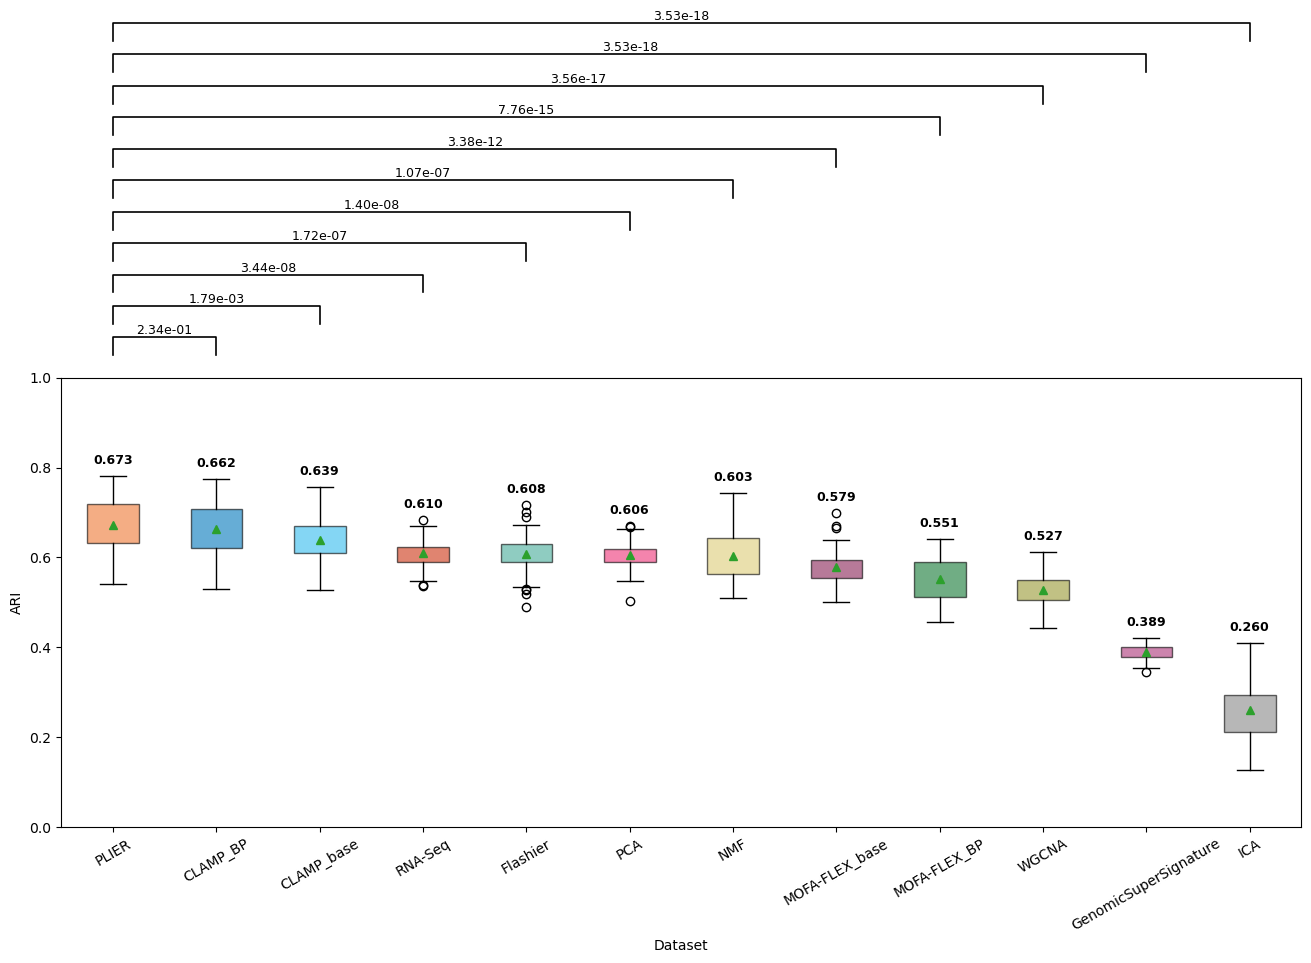

In [42]:
candidate_names = [
    "best_k_gtex_base_kmeans_results_df",
    "best_k_gtex_PLIER_kmeans_results_df",
    "best_k_gtex_rnaseq_kmeans_results_df",
    "best_k_gtex_pca_kmeans_results_df",
    "best_k_gtex_ica_kmeans_results_df",
    "best_k_gtex_nmf_kmeans_results_df",
    'best_k_gtex_mofa_kmeans_results_df',
    'best_k_gtex_mofabc_kmeans_results_df',
    'best_k_gtex_flashier_kmeans_results_df',
    "best_k_gtex_GenomicSuperSignature_kmeans_results_df",
    "best_k_gtex_GO_BP_CLAMP_kmeans_results_df",
    "best_k_gtex_wgcna_kmeans_results_df",

]

datasets = {name: globals().get(name) for name in candidate_names}
datasets = {k: v for k, v in datasets.items() if v is not None and "ari" in v.columns and len(v)}

def clean_name(name: str) -> str:
    name = re.sub(r"^best_k_gtex_", "", name)
    name = re.sub(r"_kmeans_results_df$", "", name)
    return name

display_name_map = {
    "GO_BP_CLAMP": "CLAMP_BP",
    "base": "CLAMP_base",
    "PLIER": "PLIER",
    "rnaseq": "RNA-Seq",
    "mofa": "MOFA-FLEX_base",
    "mofabc": "MOFA-FLEX_BP",
    "flashier": "Flashier",
    "GenomicSuperSignature": "GenomicSuperSignature",
    "pca": "PCA",
    "ica": "ICA",
    "nmf": "NMF",
    "wgcna": "WGCNA",
}

def get_display_name(name: str) -> str:
    cleaned = clean_name(name)
    return display_name_map.get(cleaned, cleaned)

means = {name: df["ari"].mean() for name, df in datasets.items()}
ordered_names = sorted(means, key=lambda n: means[n], reverse=True)

data = [datasets[name]["ari"].to_numpy(float) for name in ordered_names]
labels = [get_display_name(name) for name in ordered_names]

fig, ax = plt.subplots(figsize=(16, 10))

box = ax.boxplot(data, tick_labels=labels, showmeans=True, patch_artist=True, medianprops={'visible': False})

# Use consistent colors from MODEL_COLORS palette
for patch, label in zip(box["boxes"], labels):
    patch.set_facecolor(get_model_color(label))
    patch.set_alpha(0.6)

for i, d in enumerate(data):
    mean_ari = np.mean(d)
    max_val = np.max(d)
    y_pos = max_val + 0.02
    ax.text(i + 1, y_pos, f'{mean_ari:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("ARI")
ax.set_xlabel("Dataset")
plt.xticks(rotation=30, ha="center")

ax.set_ylim(0, 1)

# Compare first (top performer) vs all others
top_label = labels[0]
pairs = [(top_label, lab) for lab in labels[1:]]

def mw_p_greater(a, b):
    """One-sided test: is a significantly greater than b?"""
    return mannwhitneyu(a, b, alternative="greater").pvalue

raw_p = []
for a, b in pairs:
    i = labels.index(a)
    j = labels.index(b)
    raw_p.append(mw_p_greater(data[i], data[j]))

pvals = np.array(raw_p)

xpos = {lab: x for lab, x in zip(labels, range(1, len(labels) + 1))}

def draw_bar(ax, x1, x2, y, h, txt):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, txt, ha="center", va="bottom", fontsize=9, clip_on=False)

y_start = 1.05
bar_height = 0.04
gap = 0.03
y = y_start

for (a, b), p in zip(pairs, pvals):
    x1, x2 = sorted([xpos[a], xpos[b]])
    draw_bar(ax, x1, x2, y, bar_height, f"{p:.2e}")
    y += bar_height + gap

total_height_needed = y - y_start
top_margin = 1 - (0.95 / (1 + total_height_needed * 1.5))
plt.subplots_adjust(top=top_margin)

plt.show()

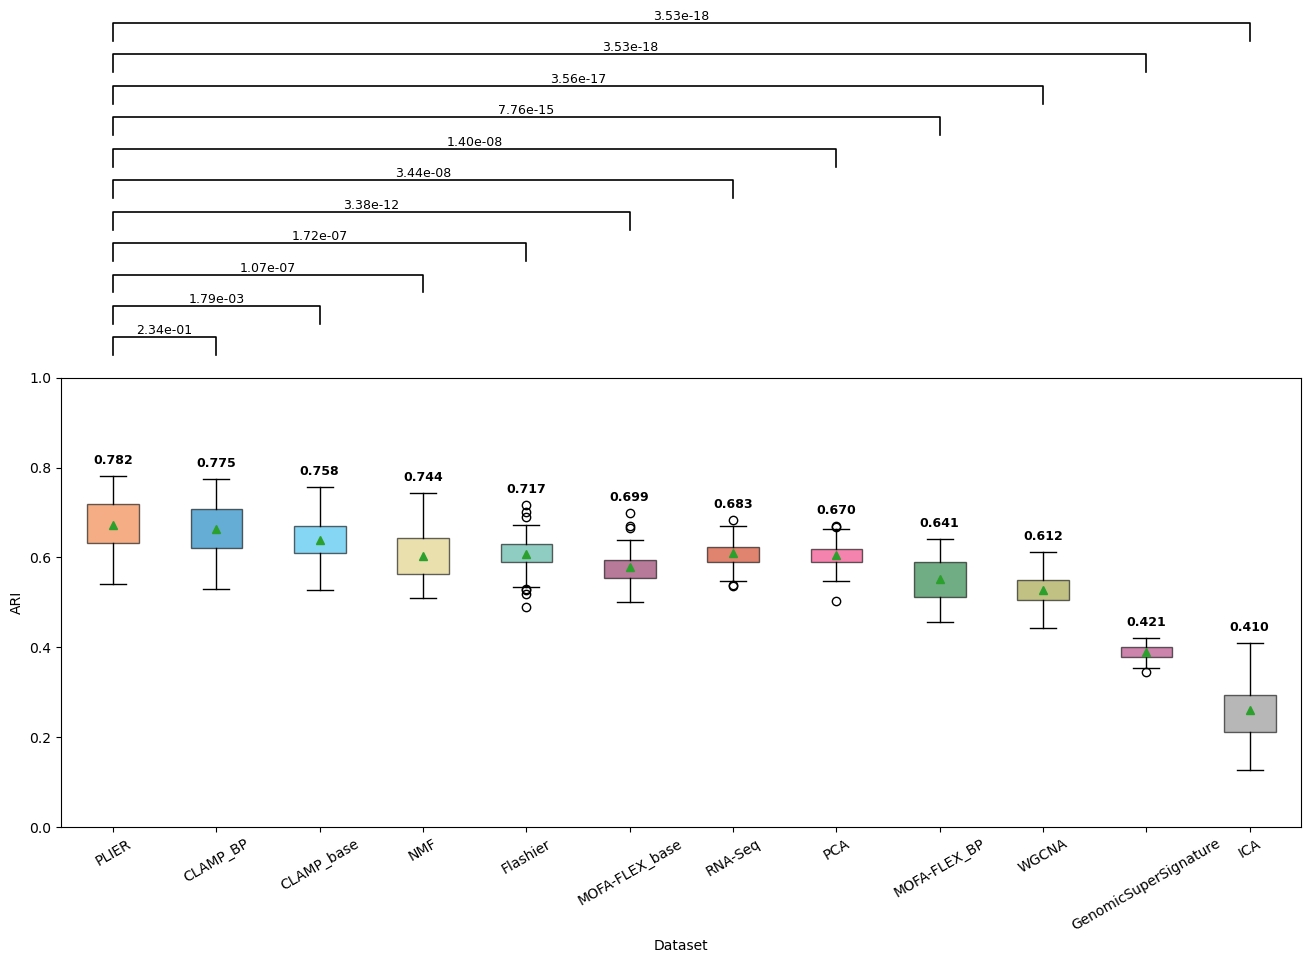

In [43]:
candidate_names = [
    "best_k_gtex_GO_BP_CLAMP_kmeans_results_df",
    "best_k_gtex_base_kmeans_results_df",
    "best_k_gtex_PLIER_kmeans_results_df",
    "best_k_gtex_rnaseq_kmeans_results_df",
    "best_k_gtex_pca_kmeans_results_df",
    "best_k_gtex_ica_kmeans_results_df",
    "best_k_gtex_nmf_kmeans_results_df",
    "best_k_gtex_mofa_kmeans_results_df",
    "best_k_gtex_mofabc_kmeans_results_df",
    "best_k_gtex_flashier_kmeans_results_df",
    "best_k_gtex_GenomicSuperSignature_kmeans_results_df",
    "best_k_gtex_wgcna_kmeans_results_df",
]

datasets = {name: globals().get(name) for name in candidate_names}
datasets = {k: v for k, v in datasets.items() if v is not None and "ari" in v.columns and len(v)}

def clean_name(name: str) -> str:
    name = re.sub(r"^best_k_gtex_", "", name)
    name = re.sub(r"_kmeans_results_df$", "", name)
    return name

display_name_map = {
    "GO_BP_CLAMP": "CLAMP_BP",
    "base": "CLAMP_base",
    "PLIER": "PLIER",
    "rnaseq": "RNA-Seq",
    "mofa": "MOFA-FLEX_base",
    "mofabc": "MOFA-FLEX_BP",
    "flashier": "Flashier",
    "GenomicSuperSignature": "GenomicSuperSignature",
    "pca": "PCA",
    "ica": "ICA",
    "nmf": "NMF",
    "wgcna": "WGCNA",
}

def get_display_name(name: str) -> str:
    cleaned = clean_name(name)
    return display_name_map.get(cleaned, cleaned)

# Order by MAX (instead of mean)
maxes = {name: df["ari"].max() for name, df in datasets.items()}
ordered_names = sorted(maxes, key=lambda n: maxes[n], reverse=True)

data = [datasets[name]["ari"].to_numpy(float) for name in ordered_names]
labels = [get_display_name(name) for name in ordered_names]

fig, ax = plt.subplots(figsize=(16, 10))

box = ax.boxplot(
    data,
    tick_labels=labels,
    showmeans=True,
    patch_artist=True,
    medianprops={"visible": False},
)

# Use consistent colors from MODEL_COLORS palette
for patch, label in zip(box["boxes"], labels):
    patch.set_facecolor(get_model_color(label))
    patch.set_alpha(0.6)

# Annotate MAX above each box
for i, d in enumerate(data):
    max_val = float(np.max(d))
    y_pos = max_val + 0.02
    ax.text(
        i + 1,
        y_pos,
        f"{max_val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_ylabel("ARI")
ax.set_xlabel("Dataset")
plt.xticks(rotation=30, ha="center")
ax.set_ylim(0, 1)

# Compare first (top by MAX) vs all others
top_label = labels[0]
pairs = [(top_label, lab) for lab in labels[1:]]

def mw_p_greater(a, b):
    """One-sided test: is a significantly greater than b?"""
    return mannwhitneyu(a, b, alternative="greater").pvalue

raw_p = []
for a, b in pairs:
    i = labels.index(a)
    j = labels.index(b)
    raw_p.append(mw_p_greater(data[i], data[j]))

pvals = np.array(raw_p)

xpos = {lab: x for lab, x in zip(labels, range(1, len(labels) + 1))}

def draw_bar(ax, x1, x2, y, h, txt):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, txt, ha="center", va="bottom", fontsize=9, clip_on=False)

y_start = 1.05
bar_height = 0.04
gap = 0.03
y = y_start

for (a, b), p in zip(pairs, pvals):
    x1, x2 = sorted([xpos[a], xpos[b]])
    draw_bar(ax, x1, x2, y, bar_height, f"{p:.2e}")
    y += bar_height + gap

total_height_needed = y - y_start
top_margin = 1 - (0.95 / (1 + total_height_needed * 1.5))
plt.subplots_adjust(top=top_margin)

plt.show()

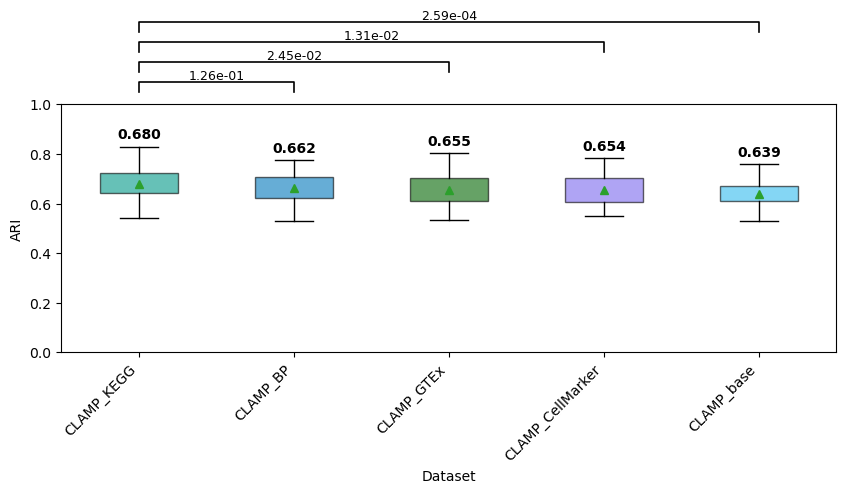

In [44]:
candidate_names = [
    "best_k_gtex_GTEx_Tissues_CLAMP_kmeans_results_df",
    "best_k_gtex_GO_BP_CLAMP_kmeans_results_df",
    "best_k_gtex_CellMarker_2024_kmeans_results_df",
    "best_k_gtex_base_kmeans_results_df",
    'best_k_gtex_KEGG_CLAMP_kmeans_results_df'
]

datasets = {name: globals().get(name) for name in candidate_names}
datasets = {k: v for k, v in datasets.items() if v is not None and "ari" in v.columns and len(v)}

def clean_name(name: str) -> str:
    name = re.sub(r"^best_k_gtex_", "", name)
    name = re.sub(r"_kmeans_results_df$", "", name)
    return name

display_name_map = {
    "GO_BP_CLAMP": "CLAMP_BP",
    "GTEx_Tissues_CLAMP": "CLAMP_GTEx",
    "CellMarker_2024": "CLAMP_CellMarker",
    "base": "CLAMP_base",
    "KEGG_CLAMP": "CLAMP_KEGG",
}

def get_display_name(name: str) -> str:
    cleaned = clean_name(name)
    return display_name_map.get(cleaned, cleaned)

means = {name: df["ari"].mean() for name, df in datasets.items()}
ordered_names = sorted(means, key=lambda n: means[n], reverse=True)

data = [datasets[name]["ari"].to_numpy(float) for name in ordered_names]
labels = [get_display_name(name) for name in ordered_names]

fig, ax = plt.subplots(figsize=(10, 10))

box = ax.boxplot(data, tick_labels=labels, showmeans=True, patch_artist=True, medianprops={'visible': False})

# Use consistent colors from MODEL_COLORS palette
for patch, label in zip(box["boxes"], labels):
    patch.set_facecolor(get_model_color(label))
    patch.set_alpha(0.6)

for i, d in enumerate(data):
    mean_ari = np.mean(d)
    max_val = np.max(d)
    y_pos = max_val + 0.02
    ax.text(i + 1, y_pos, f'{mean_ari:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel("ARI")
ax.set_xlabel("Dataset")
plt.xticks(rotation=45, ha="right")

ax.set_ylim(0, 1)

# Compare first (top performer) vs all others
top_label = labels[0]
pairs = [(top_label, lab) for lab in labels[1:]]

def mw_p_greater(a, b):
    """One-sided test: is a significantly greater than b?"""
    return mannwhitneyu(a, b, alternative="greater").pvalue

raw_p = []
for a, b in pairs:
    i = labels.index(a)
    j = labels.index(b)
    raw_p.append(mw_p_greater(data[i], data[j]))

pvals = np.array(raw_p)

xpos = {lab: x for lab, x in zip(labels, range(1, len(labels) + 1))}

def draw_bar(ax, x1, x2, y, h, txt):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, txt, ha="center", va="bottom", fontsize=9, clip_on=False)

y_start = 1.05
bar_height = 0.04
gap = 0.04
y = y_start

for (a, b), p in zip(pairs, pvals):
    x1, x2 = sorted([xpos[a], xpos[b]])
    draw_bar(ax, x1, x2, y, bar_height, f"{p:.2e}")
    y += bar_height + gap

total_height_needed = y - y_start
top_margin = 1 - (0.95 / (1 + total_height_needed * 1.5))
plt.subplots_adjust(top=top_margin)

plt.show()

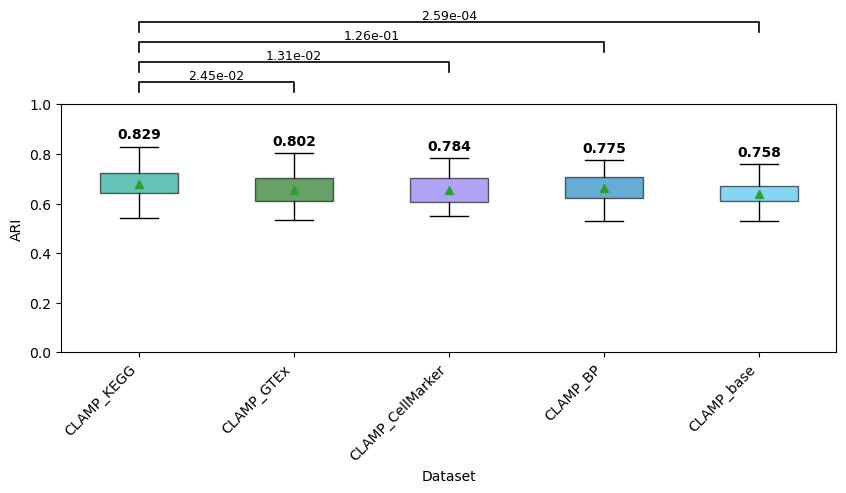

In [45]:
candidate_names = [
    "best_k_gtex_GTEx_Tissues_CLAMP_kmeans_results_df",
    "best_k_gtex_GO_BP_CLAMP_kmeans_results_df",
    "best_k_gtex_CellMarker_2024_kmeans_results_df",
    "best_k_gtex_base_kmeans_results_df",
    'best_k_gtex_KEGG_CLAMP_kmeans_results_df'
]

datasets = {name: globals().get(name) for name in candidate_names}
datasets = {k: v for k, v in datasets.items() if v is not None and "ari" in v.columns and len(v)}

def clean_name(name: str) -> str:
    name = re.sub(r"^best_k_gtex_", "", name)
    name = re.sub(r"_kmeans_results_df$", "", name)
    return name

display_name_map = {
    "GO_BP_CLAMP": "CLAMP_BP",
    "GTEx_Tissues_CLAMP": "CLAMP_GTEx",
    "CellMarker_2024": "CLAMP_CellMarker",
    "base": "CLAMP_base",
    "KEGG_CLAMP": "CLAMP_KEGG",
}

def get_display_name(name: str) -> str:
    cleaned = clean_name(name)
    return display_name_map.get(cleaned, cleaned)

# Use MAX instead of mean
maxes = {name: df["ari"].max() for name, df in datasets.items()}
ordered_names = sorted(maxes, key=lambda n: maxes[n], reverse=True)

data = [datasets[name]["ari"].to_numpy(float) for name in ordered_names]
labels = [get_display_name(name) for name in ordered_names]

fig, ax = plt.subplots(figsize=(10, 10))

box = ax.boxplot(
    data,
    tick_labels=labels,
    showmeans=True,
    patch_artist=True,
    medianprops={"visible": False},
)

# Use consistent colors from MODEL_COLORS palette
for patch, label in zip(box["boxes"], labels):
    patch.set_facecolor(get_model_color(label))
    patch.set_alpha(0.6)

# Annotate MAX above each box
for i, d in enumerate(data):
    max_val = float(np.max(d))
    y_pos = max_val + 0.02
    ax.text(
        i + 1,
        y_pos,
        f"{max_val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_ylabel("ARI")
ax.set_xlabel("Dataset")
plt.xticks(rotation=45, ha="right")
ax.set_ylim(0, 1)

# Compare first (top by MAX) vs all others
top_label = labels[0]
pairs = [(top_label, lab) for lab in labels[1:]]

def mw_p_greater(a, b):
    """One-sided test: is a significantly greater than b?"""
    return mannwhitneyu(a, b, alternative="greater").pvalue

pvals = np.array([mw_p_greater(data[0], data[labels.index(b)]) for _, b in pairs])

xpos = {lab: x for lab, x in zip(labels, range(1, len(labels) + 1))}

def draw_bar(ax, x1, x2, y, h, txt):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, txt, ha="center", va="bottom", fontsize=9, clip_on=False)

y_start = 1.05
bar_height = 0.04
gap = 0.04
y = y_start

for (a, b), p in zip(pairs, pvals):
    x1, x2 = sorted([xpos[a], xpos[b]])
    draw_bar(ax, x1, x2, y, bar_height, f"{p:.2e}")
    y += bar_height + gap

total_height_needed = y - y_start
top_margin = 1 - (0.95 / (1 + total_height_needed * 1.5))
plt.subplots_adjust(top=top_margin)

plt.show()

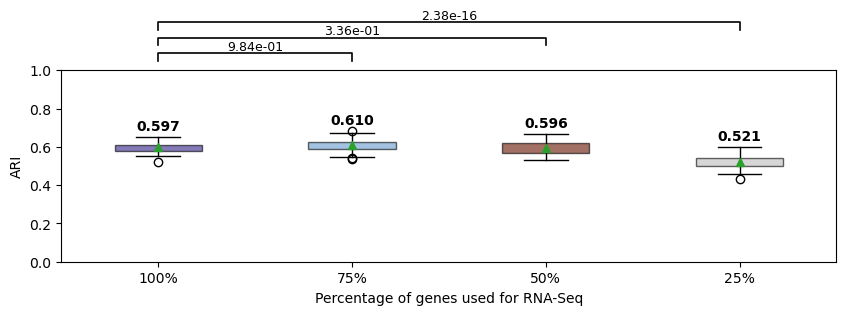

In [46]:
# RNA-Seq Gene Subsampling Comparison Plot
fraction_order = [1.0, 0.75, 0.50, 0.25]
fraction_labels = ["100%", "75%", "50%", "25%"]

# Aggregate ARI values for each fraction
aggregated_data = {}
for frac, label in zip(fraction_order, fraction_labels):
    ari_values = []
    for run_label, df in best_k_rnaseq_results.items():
        if df["frac"].iloc[0] == frac:
            ari_values.extend(df["ari"].tolist())
    aggregated_data[label] = np.array(ari_values)

# Prepare data for boxplot
data = [aggregated_data[label] for label in fraction_labels]

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

box = ax.boxplot(data, tick_labels=fraction_labels, showmeans=True, patch_artist=True, medianprops={'visible': False})

# Use consistent colors from RNASEQ_FRACTION_COLORS palette
for patch, label in zip(box["boxes"], fraction_labels):
    patch.set_facecolor(get_fraction_color(label))
    patch.set_alpha(0.6)

# Add mean ARI values above each boxplot
for i, d in enumerate(data):
    mean_ari = np.mean(d)
    max_val = np.max(d)
    y_pos = max_val + 0.02
    ax.text(i + 1, y_pos, f'{mean_ari:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel("ARI")
ax.set_xlabel("Percentage of genes used for RNA-Seq")
ax.set_ylim(0, 1)

# Compare 100% vs each other fraction
top_label = fraction_labels[0]
pairs = [(top_label, label) for label in fraction_labels[1:]]

def mw_p_greater(a, b):
    """One-sided test: is a significantly greater than b?"""
    return mannwhitneyu(a, b, alternative="greater").pvalue

raw_p = [mw_p_greater(aggregated_data[a], aggregated_data[b]) for a, b in pairs]

# Use raw p-values (no correction)
pvals = np.array(raw_p)

# Draw significance bars
xpos = {label: i + 1 for i, label in enumerate(fraction_labels)}

def draw_bar(ax, x1, x2, y, h, txt):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, txt, ha="center", va="bottom", fontsize=9, clip_on=False)

y_start = 1.05
bar_height = 0.04
gap = 0.04
y = y_start

for (a, b), p in zip(pairs, pvals):
    x1, x2 = sorted([xpos[a], xpos[b]])
    draw_bar(ax, x1, x2, y, bar_height, f"{p:.2e}")
    y += bar_height + gap

total_height_needed = y - y_start
top_margin = 1 - (0.95 / (1 + total_height_needed * 1.5))
plt.subplots_adjust(top=top_margin)

plt.show()

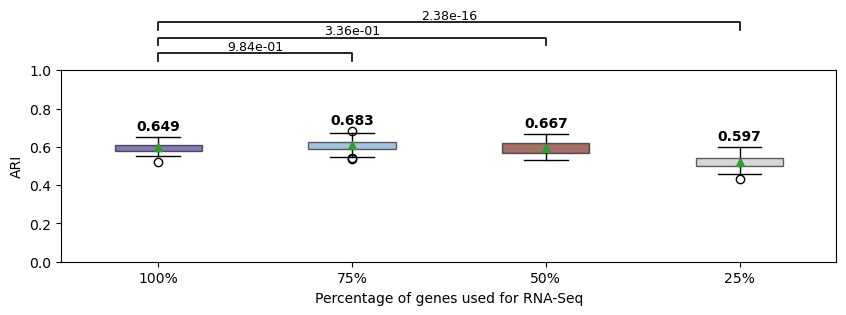

In [47]:
# RNA-Seq Gene Subsampling Comparison Plot (annotate MAX instead of mean)
fraction_order = [1.0, 0.75, 0.50, 0.25]
fraction_labels = ["100%", "75%", "50%", "25%"]

# Aggregate ARI values for each fraction
aggregated_data = {}
for frac, label in zip(fraction_order, fraction_labels):
    ari_values = []
    for run_label, df in best_k_rnaseq_results.items():
        if df["frac"].iloc[0] == frac:
            ari_values.extend(df["ari"].tolist())
    aggregated_data[label] = np.array(ari_values, dtype=float)

# Prepare data for boxplot
data = [aggregated_data[label] for label in fraction_labels]

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

box = ax.boxplot(
    data,
    tick_labels=fraction_labels,
    showmeans=True,
    patch_artist=True,
    medianprops={"visible": False},
)

# Use consistent colors from RNASEQ_FRACTION_COLORS palette
for patch, label in zip(box["boxes"], fraction_labels):
    patch.set_facecolor(get_fraction_color(label))
    patch.set_alpha(0.6)

# Add MAX ARI values above each boxplot
for i, d in enumerate(data):
    max_val = float(np.max(d))
    y_pos = max_val + 0.02
    ax.text(
        i + 1,
        y_pos,
        f"{max_val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_ylabel("ARI")
ax.set_xlabel("Percentage of genes used for RNA-Seq")
ax.set_ylim(0, 1)

# Compare 100% vs each other fraction
top_label = fraction_labels[0]
pairs = [(top_label, label) for label in fraction_labels[1:]]

def mw_p_greater(a, b):
    """One-sided test: is a significantly greater than b?"""
    return mannwhitneyu(a, b, alternative="greater").pvalue

raw_p = [mw_p_greater(aggregated_data[a], aggregated_data[b]) for a, b in pairs]
pvals = np.array(raw_p)

# Draw significance bars
xpos = {label: i + 1 for i, label in enumerate(fraction_labels)}

def draw_bar(ax, x1, x2, y, h, txt):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, txt, ha="center", va="bottom", fontsize=9, clip_on=False)

y_start = 1.05
bar_height = 0.04
gap = 0.04
y = y_start

for (a, b), p in zip(pairs, pvals):
    x1, x2 = sorted([xpos[a], xpos[b]])
    draw_bar(ax, x1, x2, y, bar_height, f"{p:.2e}")
    y += bar_height + gap

total_height_needed = y - y_start
top_margin = 1 - (0.95 / (1 + total_height_needed * 1.5))
plt.subplots_adjust(top=top_margin)

plt.show()